In [1]:
import os
import re
import string
import json
import csv
    
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from nltk.corpus import stopwords, words as nltk_words
from nltk.stem import WordNetLemmatizer

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, f1_score)
from sklearn.pipeline import Pipeline
from gensim.models import Word2Vec

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.svm import LinearSVC

import nltk

nltk.download('words')
nltk.download('wordnet')
nltk.download('stopwords')

[nltk_data] Downloading package words to
[nltk_data]     C:\Users\ilisa\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ilisa\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ilisa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
root_dir = "./data"

PLATFORM_MAP = {
    "twitter.com": "X",
    "instagram.com": "Instagram",
}
LABEL_MAP = {
    'BrandStory':    'Brand Story',
    'BTS':           'BTS',
    'Explainer':     'Explainer',
    'Humor':         'Humor',
    'IndustryNews':  'Industry News',
    'Inspirational': 'Inspirational',
    'LifestyleDaily':'Lifestyle Daily',
    'ProductLaunch': 'Product Launch',
    'SalesPromotion':'Sales Promotion',
    'TipsAndTricks': 'Tips And Tricks',
    'Tutorial':      'Tutorial',
}

def get_platform(record: dict) -> str:
    """Extract platform label from the source_platform field."""
    source = record.get("source_platform", "")
    for domain, label in PLATFORM_MAP.items():
        if domain in source:
            return label
    return "Unknown"

def get_text(record: dict, platform: str) -> str:
    data = record.get("data", {})

    if platform == "X":
        try:
            return data["note_tweet"]["note_tweet_results"]["result"]["text"]
        except (KeyError, TypeError):
            pass
        try:
            return data["legacy"]["full_text"]
        except (KeyError, TypeError):
            pass

    elif platform == "Instagram":
        try:
            return data["caption"]["text"]
        except (KeyError, TypeError):
            pass

    return record.get("text", "")

def process_ndjson(input_path: str, label: str, output_path: str):
    rows = []
    with open(input_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            record = json.loads(line)
            platform = get_platform(record)
            text = get_text(record, platform)
            if text:
                rows.append({"text": text, "label": label, "platform": platform})

    with open(output_path, "w", encoding="utf-8", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=["text", "label", "platform"])
        writer.writeheader()
        writer.writerows(rows)

    print(f"✓ {output_path}  ({len(rows)} rows)")


def main():

    for category in os.listdir(root_dir):
        category_path = os.path.join(root_dir, category)
        if not os.path.isdir(category_path):
            continue

        for filename in os.listdir(category_path):
            if not filename.endswith(".ndjson"):
                continue

            input_path = os.path.join(category_path, filename)
            output_filename = filename.replace(".ndjson", ".csv")
            output_path = os.path.join(category_path, output_filename)

            mapped_label = LABEL_MAP.get(category, category)
            process_ndjson(input_path, label=mapped_label, output_path=output_path)
            
if __name__ == "__main__":
    main()

✓ ./data\BTS\BTS_Instagram.csv  (242 rows)
✓ ./data\BTS\BTS_X.csv  (260 rows)
✓ ./data\Explainer\Explainer_Instagram.csv  (250 rows)
✓ ./data\Explainer\Explainer_X.csv  (262 rows)
✓ ./data\Humor\Humor_Instagram.csv  (501 rows)
✓ ./data\Humor\Humor_X.csv  (220 rows)
✓ ./data\IndustryNews\IndustryNews_Instagram.csv  (275 rows)
✓ ./data\IndustryNews\IndustryNews_X.csv  (220 rows)
✓ ./data\Inspirational\Inspirational_Instagram.csv  (267 rows)
✓ ./data\Inspirational\Inspirational_X.csv  (251 rows)
✓ ./data\LifestyleDaily\LifestyleDaily_Instagram.csv  (289 rows)
✓ ./data\LifestyleDaily\LifestyleDaily_X.csv  (212 rows)
✓ ./data\ProductLaunch\ProductLaunch_Instagram.csv  (1028 rows)
✓ ./data\Promotions\Promotions_Instagram.csv  (207 rows)
✓ ./data\Promotions\Promotions_X.csv  (344 rows)
✓ ./data\Tutorial\Tutorial_Instagram.csv  (87 rows)
✓ ./data\Tutorial\Tutorial_X.csv  (528 rows)


Category        | Platform     | Total  | Unique | Nulls
------------------------------------------------------------

       FINAL DATASET AUDIT
Total Rows (Combined):          5363
Global Duplicates Found:        166
Unique Tweets (Final Count):    5280
Data Reduction:                 1.55%
----------------------------------------

Final Class Distribution (Unique):
label
Product Launch     1013
Humor               684
Promotions          547
Tutorial            529
Explainer           512
Inspirational       511
BTS                 500
Lifestyle Daily     494
Industry News       490
Name: count, dtype: int64


C:\Users\ilisa\AppData\Local\Temp\ipykernel_10196\788426620.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, ax=ax1, palette='viridis')


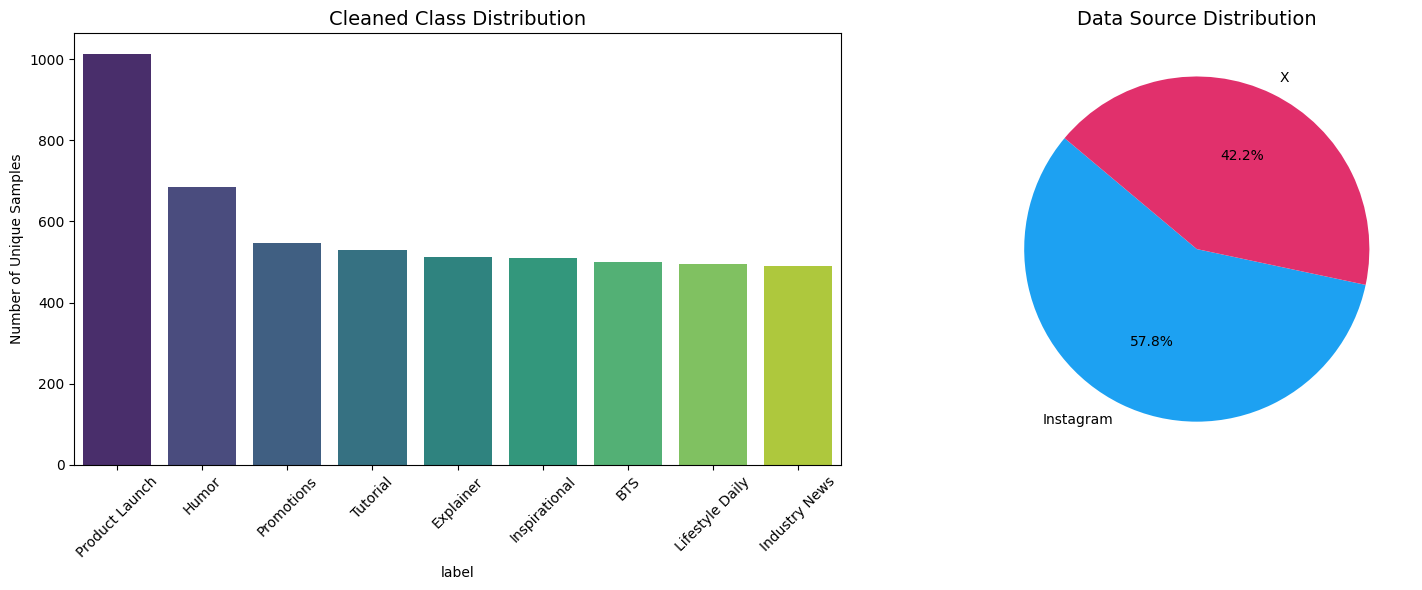


✓ Master training file saved to: ./data\master_training_dataset.csv


In [3]:
dataframes = []
print(f"{'Category':<15} | {'Platform':<12} | {'Total':<6} | {'Unique':<6} | {'Nulls':<5}")
print("-" * 60)

for category in os.listdir(root_dir):
    cat_path = os.path.join(root_dir, category)
    
    if os.path.isdir(cat_path):
        category_dfs = []
        ig_count = 0
        x_count = 0
        for root, dirs, files in os.walk(cat_path):
            for filename in files:
                if filename.endswith('.csv') and not filename.endswith('_Merged.csv'):
                    file_path = os.path.join(root, filename)
                    try:
                        df = pd.read_csv(file_path)
                        df['text'] = df['text'].astype(str).str.strip()
                        
                        platform = "Unknown"
                        if "_X.csv" in filename: platform = "X"
                        elif "_Instagram.csv" in filename: platform = "Instagram"
                        df = df.drop_duplicates(subset=['text']).copy()

                        category_dfs.append(df)
                    except Exception as e:
                        print(f"Error loading {file_path}: {e}")
            if category_dfs:
                merged_cat = pd.concat(category_dfs, ignore_index=True)
                merged_cat['text'] = merged_cat['text'].astype(str).str.strip()
                merged_cat = merged_cat.drop_duplicates(subset=['text']).reset_index(drop=True)
                
                merged_cat.to_csv(os.path.join(cat_path, f"{category}_Merged.csv"), index=False)
                dataframes.append(merged_cat)


final_dataset = pd.concat(dataframes, ignore_index=True)

duplicate_mask = final_dataset.duplicated(subset=['text'], keep=False)
total_duplicates = duplicate_mask.sum()
duplicate_samples = final_dataset[duplicate_mask].sort_values(by='text')

final_dataset_clean = final_dataset.drop_duplicates(subset=['text']).reset_index(drop=True)

print("\n" + "="*40)
print("       FINAL DATASET AUDIT")
print("="*40)
print(f"Total Rows (Combined):          {len(final_dataset)}")
print(f"Global Duplicates Found:        {total_duplicates}")
print(f"Unique Tweets (Final Count):    {len(final_dataset_clean)}")
print(f"Data Reduction:                 {((len(final_dataset)-len(final_dataset_clean))/len(final_dataset)*100):.2f}%")
print("-" * 40)

print("\nFinal Class Distribution (Unique):")
class_counts = final_dataset_clean['label'].value_counts()
print(class_counts)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=class_counts.index, y=class_counts.values, ax=ax1, palette='viridis')
ax1.set_title('Cleaned Class Distribution', fontsize=14)
ax1.set_ylabel('Number of Unique Samples')
ax1.tick_params(axis='x', rotation=45)

platform_counts = final_dataset_clean['platform'].value_counts()
ax2.pie(platform_counts, labels=platform_counts.index, autopct='%1.1f%%', 
        startangle=140, colors=['#1DA1F2', '#E1306C', '#808080']) # X Blue, IG Pink/Red
ax2.set_title('Data Source Distribution', fontsize=14)

plt.tight_layout()
plt.show()

final_dataset_clean.to_csv(os.path.join(root_dir, "master_training_dataset.csv"), index=False)
print(f"\n✓ Master training file saved to: {os.path.join(root_dir, 'master_training_dataset.csv')}")

In [4]:
english_vocab = set(w.lower() for w in nltk_words.words())
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    # Remove URLs 
    text = re.sub(r'http\S+|www\S+|@\w+|@\w+|#', '', text)
    text = re.sub(r"@\w+|#\w+", "", text) 
    # Punctuation and Numbers
    text = text.translate(str.maketrans('', '', string.punctuation))
    # text = re.sub(r'\d+', '', text)
    
    stop_words = set(stopwords.words('english'))
    tokens = text.split()
    
    clean_tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    return " ".join(clean_tokens)

main_df = pd.read_csv('./data/master_training_dataset.csv')

le = LabelEncoder()
main_df["label_enc"] = le.fit_transform(main_df["label"])
CLASSES = le.classes_

X_train, X_test, y_train, y_test = train_test_split(
    main_df["text"], main_df["label_enc"],
    test_size=0.2, random_state=42, stratify=main_df["label_enc"]
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

X_train_c = X_train.map(clean)
X_test_c  = X_test.map(clean)

Train: 4224 | Test: 1056


In [5]:
res = {}

def evaluate(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="weighted")
    rep = classification_report(y_true, y_pred, target_names=CLASSES)
    cm  = confusion_matrix(y_true, y_pred)
    res[name] = dict(accuracy=acc, f1=f1, report=rep, cm=cm)
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Accuracy : {acc:.4f}   Weighted F1 : {f1:.4f}")
    print(rep)

def plot_cm(name, cm):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(f"Confusion Matrix — {name}", fontsize=14)
    plt.ylabel("True Label"); plt.xlabel("Predicted Label")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(f"cm_{name.replace(' ','_')}.png", dpi=150)
    plt.show()

Train: 4224 | Test: 1056

>>> Running: BoW + SVM

  BoW + SVM
  Accuracy : 0.9356   Weighted F1 : 0.9354
                 precision    recall  f1-score   support

            BTS       0.98      0.94      0.96       100
      Explainer       0.98      0.95      0.97       102
          Humor       0.95      0.99      0.97       137
  Industry News       0.95      0.97      0.96        98
  Inspirational       1.00      0.98      0.99       102
Lifestyle Daily       0.96      0.98      0.97        99
 Product Launch       1.00      1.00      1.00       203
     Promotions       0.81      0.72      0.76       109
       Tutorial       0.75      0.82      0.78       106

       accuracy                           0.94      1056
      macro avg       0.93      0.93      0.93      1056
   weighted avg       0.94      0.94      0.94      1056



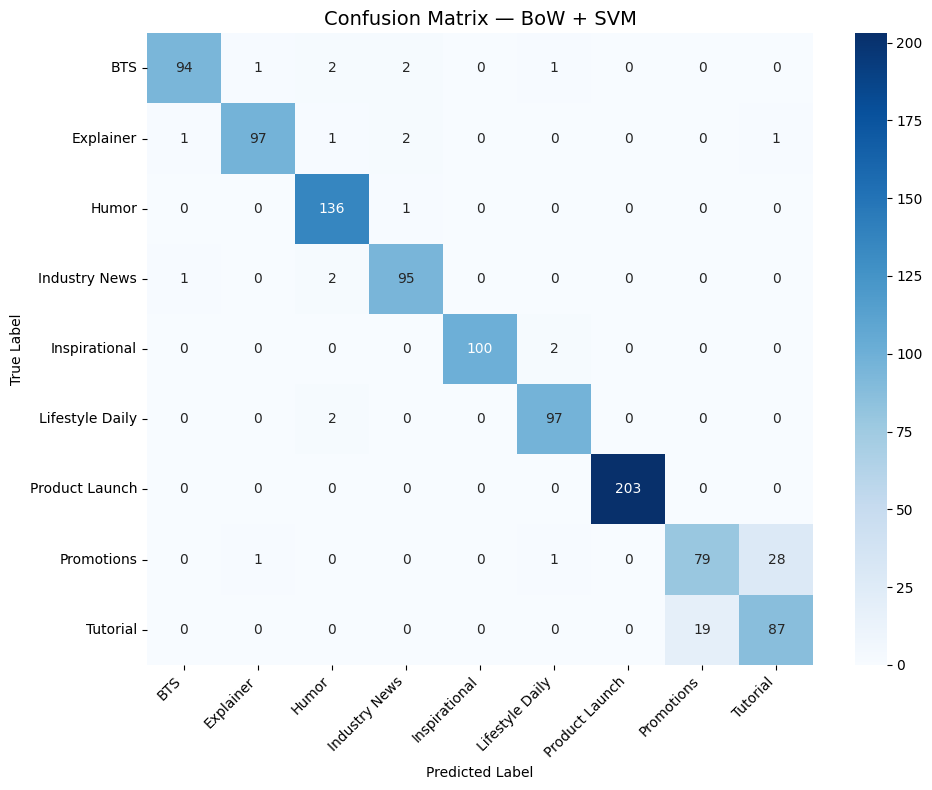


>>> Running: TF-IDF + SVM

  TF-IDF + SVM
  Accuracy : 0.9375   Weighted F1 : 0.9373
                 precision    recall  f1-score   support

            BTS       0.96      0.94      0.95       100
      Explainer       0.98      0.93      0.95       102
          Humor       0.99      0.99      0.99       137
  Industry News       0.94      0.96      0.95        98
  Inspirational       0.99      1.00      1.00       102
Lifestyle Daily       1.00      0.99      0.99        99
 Product Launch       0.98      1.00      0.99       203
     Promotions       0.83      0.72      0.77       109
       Tutorial       0.74      0.84      0.79       106

       accuracy                           0.94      1056
      macro avg       0.93      0.93      0.93      1056
   weighted avg       0.94      0.94      0.94      1056



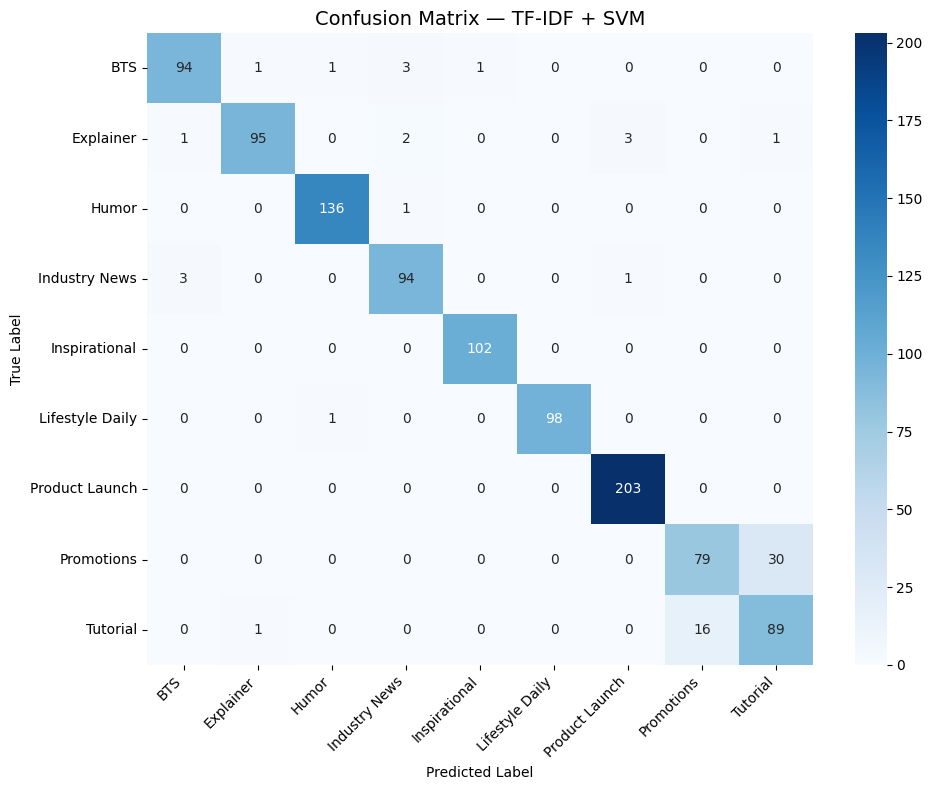


>>> Running: Word2Vec + SVM

  Word2Vec + SVM
  Accuracy : 0.7566   Weighted F1 : 0.7513
                 precision    recall  f1-score   support

            BTS       0.66      0.57      0.61       100
      Explainer       0.66      0.61      0.63       102
          Humor       0.92      0.79      0.85       137
  Industry News       0.74      0.86      0.79        98
  Inspirational       0.79      0.76      0.78       102
Lifestyle Daily       0.80      0.88      0.84        99
 Product Launch       0.89      0.99      0.93       203
     Promotions       0.59      0.43      0.50       109
       Tutorial       0.57      0.71      0.63       106

       accuracy                           0.76      1056
      macro avg       0.74      0.73      0.73      1056
   weighted avg       0.75      0.76      0.75      1056



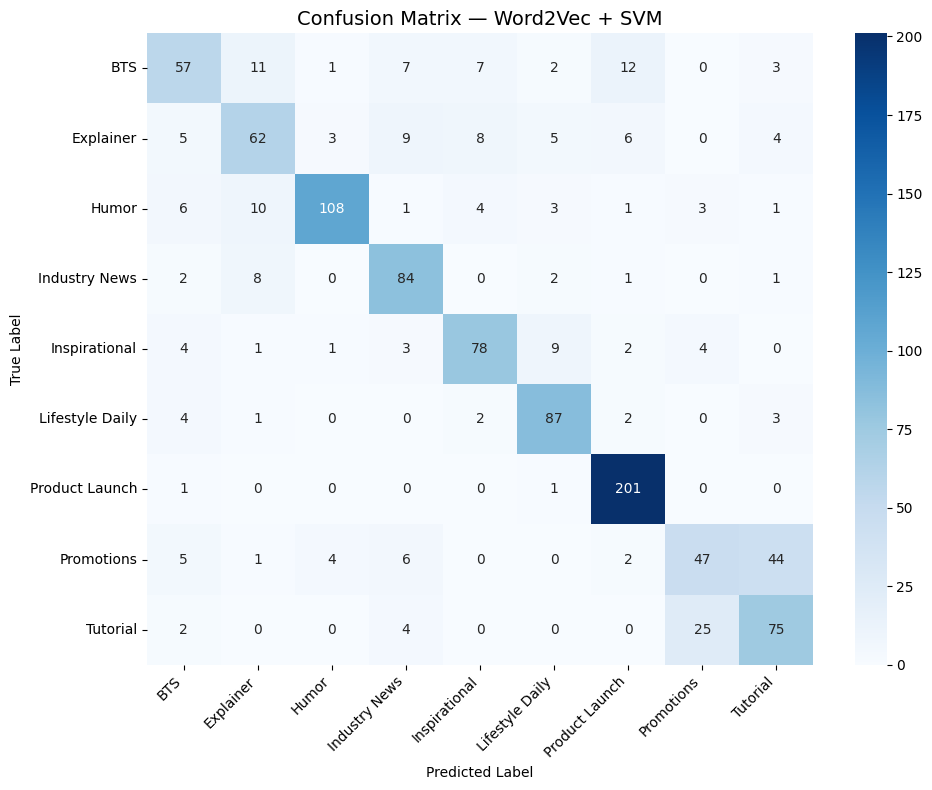

In [6]:
le = LabelEncoder()
main_df["label_enc"] = le.fit_transform(main_df["label"])
CLASSES = le.classes_

X_train, X_test, y_train, y_test = train_test_split(
    main_df["text"], main_df["label_enc"],
    test_size=0.2, random_state=42, stratify=main_df["label_enc"]
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
# SVM
# Bag Of Words
print("\n>>> Running: BoW + SVM")
bow_pipe = Pipeline([
    ("vec", CountVectorizer(max_features=50_000, ngram_range=(1, 2))),
    ("clf", LinearSVC(max_iter=2000, C=1.0))
])
bow_pipe.fit(X_train_c, y_train)
y_pred_bow = bow_pipe.predict(X_test_c)
evaluate("BoW + SVM", y_test, y_pred_bow)
plot_cm("BoW + SVM", res["BoW + SVM"]["cm"])

# TF-IDF
print("\n>>> Running: TF-IDF + SVM")
tfidf_pipe = Pipeline([
    ("vec", TfidfVectorizer(max_features=50_000, ngram_range=(1, 2),
                            sublinear_tf=True)),
    ("clf", LinearSVC(max_iter=2000, C=1.0))
])
tfidf_pipe.fit(X_train_c, y_train)
y_pred_tfidf = tfidf_pipe.predict(X_test_c)
evaluate("TF-IDF + SVM", y_test, y_pred_tfidf)
plot_cm("TF-IDF + SVM", res["TF-IDF + SVM"]["cm"])

# WORD2VEC
print("\n>>> Running: Word2Vec + SVM")

def avg_w2v(texts, model, size):
    vecs = []
    for t in texts:
        tokens = t.split()
        v = [model.wv[w] for w in tokens if w in model.wv]
        vecs.append(np.mean(v, axis=0) if v else np.zeros(size))
    return np.array(vecs)

W2V_DIM = 200
tokenized_train = [t.split() for t in X_train_c]
w2v_model = Word2Vec(tokenized_train, vector_size=W2V_DIM,
                     window=5, min_count=2, workers=4, epochs=10)

X_train_w2v = avg_w2v(X_train_c, w2v_model, W2V_DIM)
X_test_w2v  = avg_w2v(X_test_c,  w2v_model, W2V_DIM)

w2v_svm = LinearSVC(max_iter=3000, C=1.0)
w2v_svm.fit(X_train_w2v, y_train)
y_pred_w2v = w2v_svm.predict(X_test_w2v)
evaluate("Word2Vec + SVM", y_test, y_pred_w2v)
plot_cm("Word2Vec + SVM", res["Word2Vec + SVM"]["cm"])


  INPUT TEXT:
  "Just dropped our new skincare line 🧴✨ Get 20% off this weekend only! Link in bio 👇"
  Cleaned : "dropped new skincare line get weekend link bio"
  Model                | Predicted Class      | Confidence
------------------------------------------------------------
  BoW + SVM            | Promotions           | 18.80%
  TF-IDF + SVM         | Promotions           | 16.41%
  Word2Vec + SVM       | Industry News        | 36.82%
  🗳️  Majority Vote     | Promotions           |


C:\Users\ilisa\AppData\Local\Temp\ipykernel_10196\3810333453.py:96: UserWarning: Glyph 129524 (\N{LOTION BOTTLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ilisa\AppData\Local\Temp\ipykernel_10196\3810333453.py:96: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ilisa\AppData\Local\Temp\ipykernel_10196\3810333453.py:97: UserWarning: Glyph 129524 (\N{LOTION BOTTLE}) missing from font(s) DejaVu Sans.
  plt.savefig("prediction_comparison.png", dpi=150)
C:\Users\ilisa\AppData\Local\Temp\ipykernel_10196\3810333453.py:97: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  plt.savefig("prediction_comparison.png", dpi=150)
c:\Users\ilisa\Desktop\SEM2\NLP\project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129524 (\N{LOTION BOTTLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ilisa\Desktop\SEM2\NLP\project\.venv\Lib\site-p

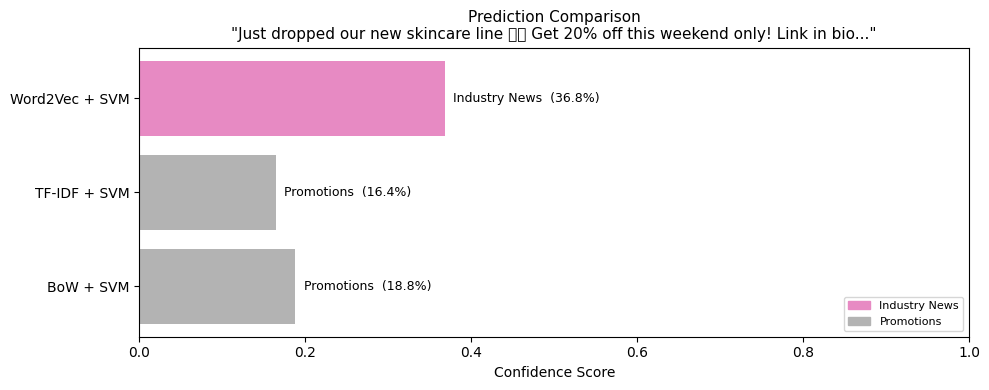


  INPUT TEXT:
  "Step-by-step guide to setting up your first Python environment 🐍"
  Cleaned : "stepbystep guide setting first python environment"
  Model                | Predicted Class      | Confidence
------------------------------------------------------------
  BoW + SVM            | Humor                | 14.00%
  TF-IDF + SVM         | Explainer            | 14.35%
  Word2Vec + SVM       | Product Launch       | 13.59%
  🗳️  Majority Vote     | Humor                |


C:\Users\ilisa\AppData\Local\Temp\ipykernel_10196\3810333453.py:96: UserWarning: Glyph 128013 (\N{SNAKE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ilisa\AppData\Local\Temp\ipykernel_10196\3810333453.py:97: UserWarning: Glyph 128013 (\N{SNAKE}) missing from font(s) DejaVu Sans.
  plt.savefig("prediction_comparison.png", dpi=150)
c:\Users\ilisa\Desktop\SEM2\NLP\project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128013 (\N{SNAKE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


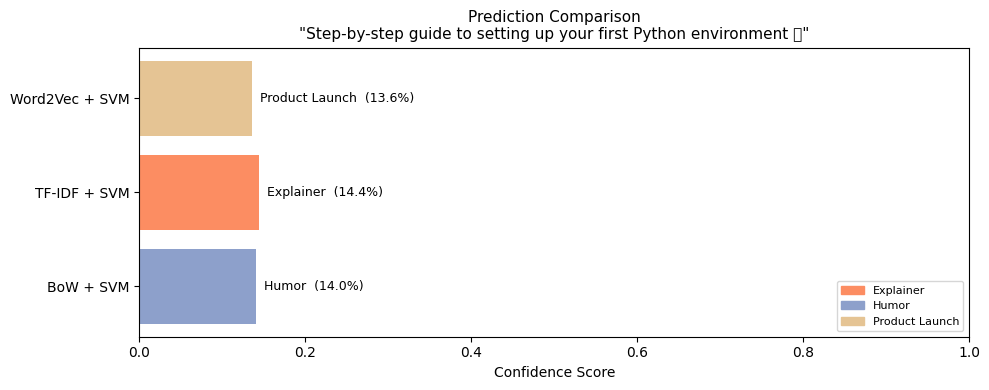


  INPUT TEXT:
  "Can't stop laughing at this video of a cat stealing pizza 😂😂"
  Cleaned : "cant stop laughing video cat stealing pizza"
  Model                | Predicted Class      | Confidence
------------------------------------------------------------
  BoW + SVM            | Humor                | 16.13%
  TF-IDF + SVM         | Humor                | 16.80%
  Word2Vec + SVM       | Humor                | 15.60%
  🗳️  Majority Vote     | Humor                |


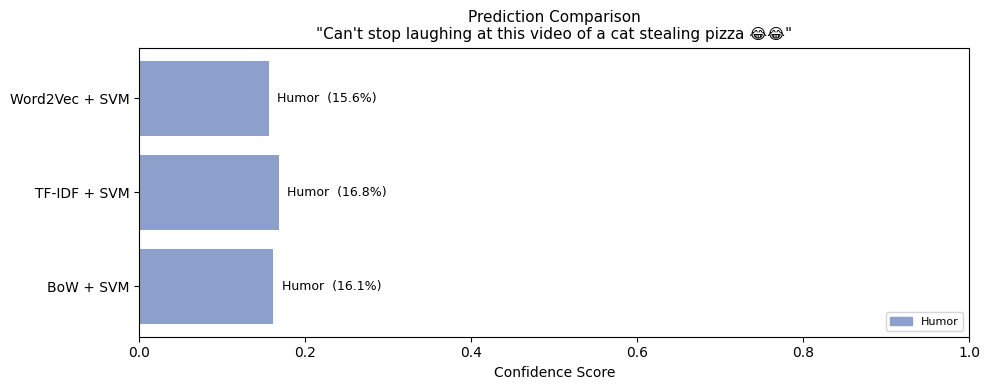


  INPUT TEXT:
  "Excited to announce we're launching our new app next Monday! 🚀"
  Cleaned : "excited announce launching new app next monday"
  Model                | Predicted Class      | Confidence
------------------------------------------------------------
  BoW + SVM            | BTS                  | 14.35%
  TF-IDF + SVM         | Product Launch       | 14.29%
  Word2Vec + SVM       | Product Launch       | 64.57%
  🗳️  Majority Vote     | Product Launch       |


C:\Users\ilisa\AppData\Local\Temp\ipykernel_10196\3810333453.py:96: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ilisa\AppData\Local\Temp\ipykernel_10196\3810333453.py:97: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  plt.savefig("prediction_comparison.png", dpi=150)
c:\Users\ilisa\Desktop\SEM2\NLP\project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


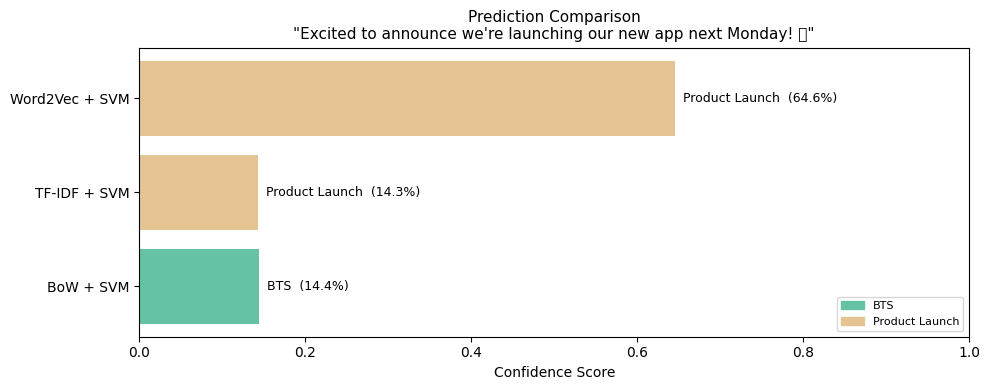


  INPUT TEXT:
  "Behind the scenes with our team getting ready for the big shoot 📸"
  Cleaned : "behind scenes team getting ready big shoot"
  Model                | Predicted Class      | Confidence
------------------------------------------------------------
  BoW + SVM            | BTS                  | 48.90%
  TF-IDF + SVM         | BTS                  | 80.82%
  Word2Vec + SVM       | BTS                  | 94.87%
  🗳️  Majority Vote     | BTS                  |


C:\Users\ilisa\AppData\Local\Temp\ipykernel_10196\3810333453.py:96: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ilisa\AppData\Local\Temp\ipykernel_10196\3810333453.py:97: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
  plt.savefig("prediction_comparison.png", dpi=150)
c:\Users\ilisa\Desktop\SEM2\NLP\project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


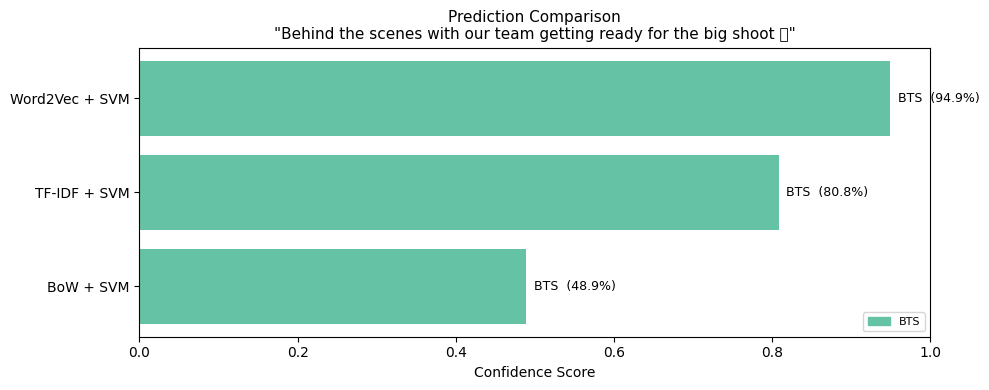


  INPUT TEXT:
  "The Fed just raised interest rates again — what this means for crypto"
  Cleaned : "fed raised interest rates means crypto"
  Model                | Predicted Class      | Confidence
------------------------------------------------------------
  BoW + SVM            | Inspirational        | 13.75%
  TF-IDF + SVM         | Industry News        | 15.77%
  Word2Vec + SVM       | Industry News        | 15.57%
  🗳️  Majority Vote     | Industry News        |


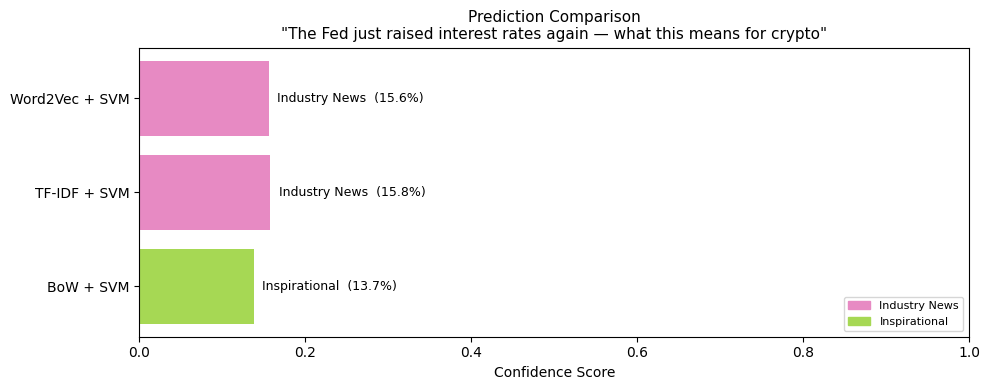


  INPUT TEXT:
  "Morning routine that changed my life ☀️ #lifestyle #selfcare"
  Cleaned : "morning routine changed life lifestyle selfcare"
  Model                | Predicted Class      | Confidence
------------------------------------------------------------
  BoW + SVM            | Lifestyle Daily      | 73.53%
  TF-IDF + SVM         | Lifestyle Daily      | 83.13%
  Word2Vec + SVM       | Lifestyle Daily      | 99.30%
  🗳️  Majority Vote     | Lifestyle Daily      |


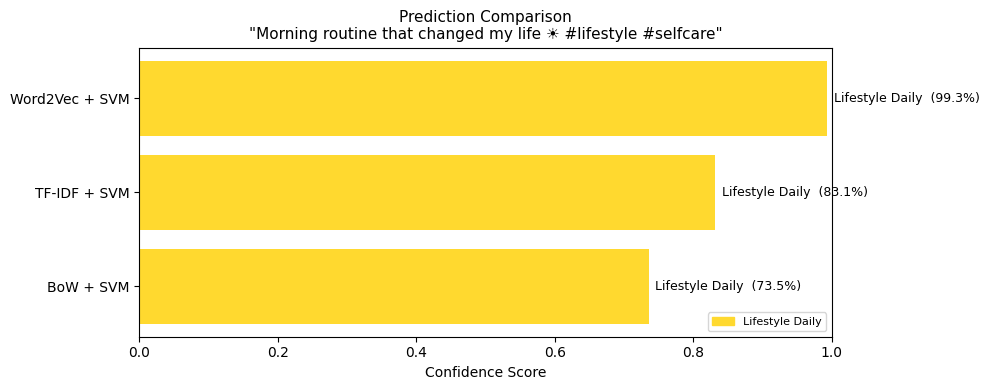


  INPUT TEXT:
  "BTS just dropped a surprise single and the internet is going crazy 🎵"
  Cleaned : "bts dropped surprise single internet going crazy"
  Model                | Predicted Class      | Confidence
------------------------------------------------------------
  BoW + SVM            | Humor                | 15.78%
  TF-IDF + SVM         | BTS                  | 13.63%
  Word2Vec + SVM       | BTS                  | 13.96%
  🗳️  Majority Vote     | BTS                  |


C:\Users\ilisa\AppData\Local\Temp\ipykernel_10196\3810333453.py:96: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ilisa\AppData\Local\Temp\ipykernel_10196\3810333453.py:97: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  plt.savefig("prediction_comparison.png", dpi=150)
c:\Users\ilisa\Desktop\SEM2\NLP\project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


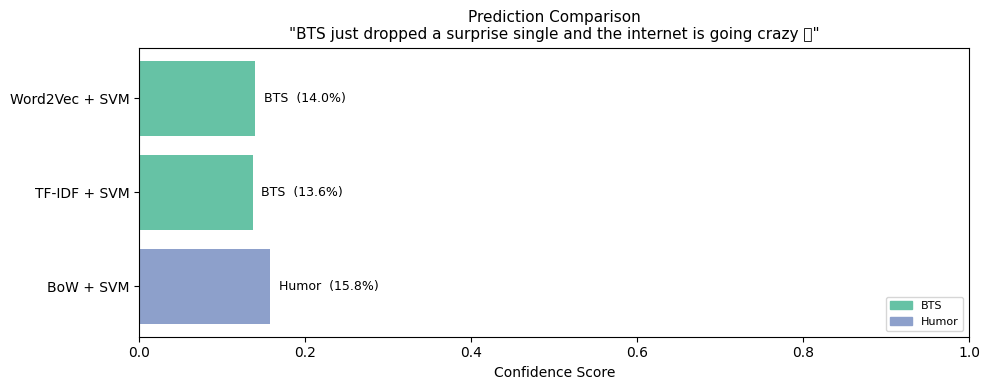


  INPUT TEXT:
  "Success is not final, failure is not fatal. Keep going 💪 #motivation"
  Cleaned : "success final failure fatal keep going motivation"
  Model                | Predicted Class      | Confidence
------------------------------------------------------------
  BoW + SVM            | Inspirational        | 64.98%
  TF-IDF + SVM         | Inspirational        | 54.30%
  Word2Vec + SVM       | Inspirational        | 24.61%
  🗳️  Majority Vote     | Inspirational        |


C:\Users\ilisa\AppData\Local\Temp\ipykernel_10196\3810333453.py:96: UserWarning: Glyph 128170 (\N{FLEXED BICEPS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ilisa\AppData\Local\Temp\ipykernel_10196\3810333453.py:97: UserWarning: Glyph 128170 (\N{FLEXED BICEPS}) missing from font(s) DejaVu Sans.
  plt.savefig("prediction_comparison.png", dpi=150)
c:\Users\ilisa\Desktop\SEM2\NLP\project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128170 (\N{FLEXED BICEPS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


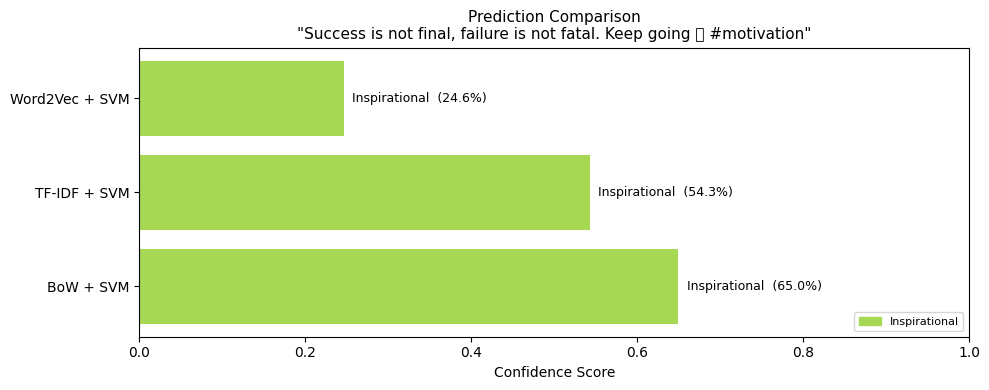


  INPUT TEXT:
  "Learn how neural networks actually work in 60 seconds ⚡"
  Cleaned : "learn neural networks actually work seconds"
  Model                | Predicted Class      | Confidence
------------------------------------------------------------
  BoW + SVM            | Explainer            | 26.81%
  TF-IDF + SVM         | Explainer            | 31.74%
  Word2Vec + SVM       | BTS                  | 18.77%
  🗳️  Majority Vote     | Explainer            |


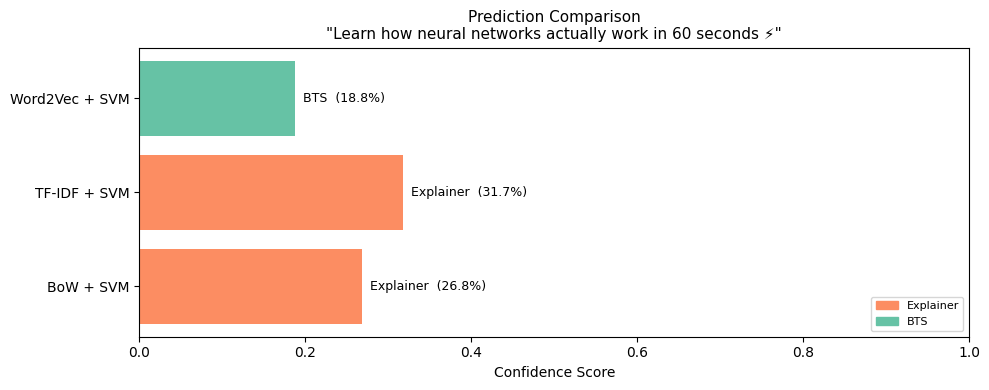

In [7]:
# ============================================================
#  6. INTERACTIVE PREDICTION TESTER
# ============================================================

def predict_all_models(text: str):
    """Run a text through all trained models and compare predictions."""
    
    text_clean = clean(text)
    
    print("\n" + "="*60)
    print(f"  INPUT TEXT:")
    print(f"  \"{text}\"")
    print("="*60)
    print(f"  Cleaned : \"{text_clean}\"")
    print("="*60)
    print(f"  {'Model':<20} | {'Predicted Class':<20} | {'Confidence'}")
    print("-"*60)
    
    predictions = {}

    # --- BoW + SVM ---
    pred = bow_pipe.predict([text_clean])[0]
    label = le.inverse_transform([pred])[0]
    # LinearSVC has decision_function, not predict_proba
    score = bow_pipe.decision_function([text_clean])[0]
    conf = softmax(score)
    predictions["BoW + SVM"] = (label, conf.max())
    print(f"  {'BoW + SVM':<20} | {label:<20} | {conf.max():.2%}")

    # --- TF-IDF + SVM ---
    pred = tfidf_pipe.predict([text_clean])[0]
    label = le.inverse_transform([pred])[0]
    score = tfidf_pipe.decision_function([text_clean])[0]
    conf = softmax(score)
    predictions["TF-IDF + SVM"] = (label, conf.max())
    print(f"  {'TF-IDF + SVM':<20} | {label:<20} | {conf.max():.2%}")

    # --- Word2Vec + SVM ---
    vec = avg_w2v([text_clean], w2v_model, W2V_DIM)
    pred = w2v_svm.predict(vec)[0]
    label = le.inverse_transform([pred])[0]
    score = w2v_svm.decision_function(vec)[0]
    conf = softmax(score)
    predictions["Word2Vec + SVM"] = (label, conf.max())
    print(f"  {'Word2Vec + SVM':<20} | {label:<20} | {conf.max():.2%}")


    # --- Majority vote ---
    from collections import Counter
    all_labels = [v[0] for v in predictions.values()]
    majority = Counter(all_labels).most_common(1)[0][0]
    print(f"  🗳️  Majority Vote     | {majority:<20} |")
    print("="*60)

    # --- Confidence bar chart ---
    plot_prediction_bars(text, predictions)

    return predictions


def softmax(x):
    e = np.exp(x - np.max(x))
    return e / e.sum()


def plot_prediction_bars(text, predictions):
    """Bar chart of confidence per model, colored by predicted class."""
    
    unique_labels = list(set(v[0] for v in predictions.values()))
    palette = plt.cm.Set2(np.linspace(0, 1, len(CLASSES)))
    color_map = {cls: palette[i] for i, cls in enumerate(CLASSES)}

    fig, ax = plt.subplots(figsize=(10, 4))
    models = list(predictions.keys())
    confs  = [predictions[m][1] for m in models]
    labels = [predictions[m][0] for m in models]
    colors = [color_map[l] for l in labels]

    bars = ax.barh(models, confs, color=colors)
    ax.set_xlim(0, 1)
    ax.set_xlabel("Confidence Score")
    ax.set_title(f"Prediction Comparison\n\"{text[:80]}{'...' if len(text)>80 else ''}\"",
                 fontsize=11)

    for bar, conf, lbl in zip(bars, confs, labels):
        ax.text(bar.get_width() + 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{lbl}  ({conf:.1%})",
                va="center", fontsize=9)

    # Legend for classes that appear
    from matplotlib.patches import Patch
    legend_patches = [Patch(color=color_map[c], label=c) for c in unique_labels]
    ax.legend(handles=legend_patches, loc="lower right", fontsize=8)

    plt.tight_layout()
    plt.savefig("prediction_comparison.png", dpi=150)
    plt.show()


# ============================================================
#  7. TEST IT — plug in any text
# ============================================================

# Single prediction
predict_all_models(
    "Just dropped our new skincare line 🧴✨ Get 20% off this weekend only! Link in bio 👇"
)

# --- Or loop over several examples at once ---
test_texts = [
    "Step-by-step guide to setting up your first Python environment 🐍",
    "Can't stop laughing at this video of a cat stealing pizza 😂😂",
    "Excited to announce we're launching our new app next Monday! 🚀",
    "Behind the scenes with our team getting ready for the big shoot 📸",
    "The Fed just raised interest rates again — what this means for crypto",
    "Morning routine that changed my life ☀️ #lifestyle #selfcare",
    "BTS just dropped a surprise single and the internet is going crazy 🎵",
    "Success is not final, failure is not fatal. Keep going 💪 #motivation",
    "Learn how neural networks actually work in 60 seconds ⚡",
]

for t in test_texts:
    predict_all_models(t)